# Human In The Loop

In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# Test the LLMs
response = remote_llm.invoke("Tell me a very short joke.")
response.pretty_print()

================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


<br><hr>

# Human In The Loop

<br>

<img src="https://i.postimg.cc/fLCHKMPB/image.png" width=500> </img>

<br>

- To review, edit, and approve tool calls in an agent or workflow, use LangGraph's `human-in-the-loop` features to enable human intervention at any point in a workflow. 

- This is especially useful in large language model (LLM)-driven applications where model output may require validation, correction, or additional context.

### Key capabilities

- **`Persistent execution state`**: Interrupts use LangGraph's persistence layer, which saves the graph state, to indefinitely pause graph execution until you resume. This is possible because LangGraph checkpoints the graph state after each step, which allows the system to persist execution context and later resume the workflow, continuing from where it left off. This supports asynchronous human review or input without time constraints.

- There are two ways to pause a graph:

  - `Dynamic interrupts`: Use `interrupt` to pause a graph from inside a specific node, based on the current state of the graph.
  - `Static interrupts`: Use `interrupt_before` and `interrupt_after` to pause the graph at pre-defined points, either before or after a node executes.

- **`Flexible integration points`**: Human-in-the-loop logic can be introduced at any point in the workflow. This allows targeted human involvement, such as approving API calls, correcting outputs, or guiding conversations.


### Patterns

There are four typical design patterns that you can implement using interrupt and Command:

- **Approve or reject**: Pause the graph before a critical step, such as an API call, to review and approve the action. If the action is rejected, you can prevent the graph from executing the step, and potentially take an alternative action. This pattern often involves routing the graph based on the human's input.

- **Edit graph state**: Pause the graph to review and edit the graph state. This is useful for correcting mistakes or updating the state with additional information. This pattern often involves updating the state with the human's input.

- **Review tool calls**: Pause the graph to review and edit tool calls requested by the LLM before tool execution.

- **Validate human input**: Pause the graph to validate human input before proceeding with the next step.

In [5]:
from typing import Annotated, TypedDict

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph.message import add_messages

In [6]:
from IPython.display import Image, Markdown, display
from langchain_core.runnables import RunnableConfig
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

## Approve or Reject Pattern

In [7]:
from enum import Enum

# For human-in-the-loop
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field

type PydanticModel = type[BaseModel]


class Status(str, Enum):
    PENDING = "pending"
    APPROVED = "approved"
    REJECTED = "rejected"


class ApprovalState(TypedDict):
    action_details: str
    status: str | None


# ==================================================================
# ============================= LLMS ===============================
# ==================================================================

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.85,
    model=RemoteModel.X_AI_GROK_4_FAST,
)

In [8]:
# ==================================================================
# ============================= NODES ==============================
# ==================================================================


def approval_node(state: ApprovalState) -> Command[Literal["proceed", "cancel"]]:
    """Approval node for human-in-the-loop decision making."""
    # Expose details so the caller can render them in a UI
    decision = interrupt(
        {
            "question": "Approve this action?",
            "details": state["action_details"],
        }
    )

    # Route to the appropriate node after resume
    return Command(goto="proceed" if decision else "cancel")


def proceed_node(state: ApprovalState) -> dict[str, str]:
    """Node to handle approved actions."""
    console.print("[green]✅ Action has been approved![/green]")
    return {"status": Status.APPROVED}


def cancel_node(state: ApprovalState):
    """Node to handle rejected actions."""
    console.print("[red]❌ Action has been rejected![/red]")
    return {"status": Status.REJECTED}

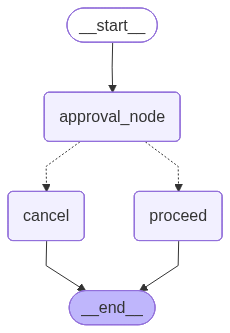

In [9]:
builder = StateGraph(ApprovalState)

# Nodes
builder.add_node("approval_node", approval_node)
builder.add_node("proceed", proceed_node)
builder.add_node("cancel", cancel_node)


# Edges
builder.add_edge(START, "approval_node")
builder.add_edge("proceed", END)
builder.add_edge("cancel", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Configurable thread ID
config: dict[str, Any] = {"configurable": {"thread_id": "approval-command-123"}}

# Visualize the graph using nest_asyncio to handle event loop
try:
    display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    print(graph.get_graph(xray=1).draw_ascii())


# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

In [10]:
# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

response = await graph.ainvoke(
    {"action_details": "Transfer $500 to savings account"},
    config=config,
)

<br>

#### Step 1: View the interrupt

In [11]:
# Step 1: View the interrupt
console.print("[cyan]Step 1: Workflow paused for human decision[/cyan]")
print("Interrupt details:")
console.print(response["__interrupt__"])

Step 1: Workflow paused for human decision

Interrupt details:


[
    Interrupt(
        value={'question': 'Approve this action?', 'details': 'Transfer $500 to savings account'},
        id='e351b437c31c7553ae50979d26395168'
    )
]

<br>

#### Step 2: Simulate human approval by resuming the graph with a decision

In [12]:
# Step 2: Simulate human approval by resuming the graph with a decision
console.print("[yellow]Human Decision: APPROVE (True)[/yellow]")
resumed = await graph.ainvoke(Command(resume=True), config=config)  # True = approve
console.print(f"[green]Final result: {resumed}[/green]")

Human Decision: APPROVE (True)

✅ Action has been approved!

Final result: {'action_details': 'Transfer $500 to savings account', 'status': <Status.APPROVED: 'approved'>}

<br>

#### Step 3: Demonstrate rejection flow

In [ ]:
# New config for rejection demo
reject_config: dict[str, Any] = {"configurable": {"thread_id": "approval-reject-456"}}

# Start workflow with potentially dangerous action
reject_response = await graph.ainvoke(
    {"action_details": "Delete all user data permanently"},
    config=reject_config,
)

console.print(f"Action to review: {reject_response.get('action_details', 'Unknown action')}")

# Human rejects the action (resume=False)
reject_result = await graph.ainvoke(Command(resume=False), config=reject_config)
console.print(f"Final result: {reject_result}")

Action to review: Delete all user data permanently

❌ Action has been rejected!

Final result: {'action_details': 'Delete all user data permanently', 'status': <Status.REJECTED: 'rejected'>}

## Edit Graph State Pattern

- Sometimes you want to let a human review and edit part of the graph state before continuing. This is useful for correcting LLMs, adding missing information, or making adjustments.

In [14]:
# ==================================================================
# ============================= STATES =============================
# ==================================================================
class ReviewState(TypedDict):
    generated_text: str


# ==================================================================
# ============================= NODES ==============================
# ==================================================================
def review_node(state: ReviewState) -> dict[str, Any]:
    # Ask a reviewer to edit the enerated content
    updated = interrupt(
        {
            "instruction": "Review and edit this content",
            "content": state["generated_text"],
        }
    )

    return {"generated_text": updated}

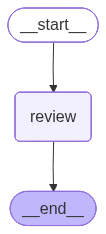

In [15]:
builder = StateGraph(ReviewState)

# Nodes
builder.add_node("review", review_node)

# Edges
builder.add_edge(START, "review")
builder.add_edge("review", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Configurable thread ID
config: dict[str, Any] = {"configurable": {"thread_id": "review-123"}}

# Visualize the graph using nest_asyncio to handle event loop
try:
    display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    print(graph.get_graph(xray=1).draw_ascii())


# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

<br>

#### Step 1: The graph is interrupted (paused)

In [16]:
# Step 1: The graph is interrupted (paused)
response = await graph.ainvoke({"generated_text": "Initial draft"}, config=config)
console.print(response["__interrupt__"])

[
    Interrupt(
        value={'instruction': 'Review and edit this content', 'content': 'Initial draft'},
        id='31d9aa2c755f9dc19017fa5f771fa506'
    )
]

#### Step 2: Resume with the edited text from the reviewer


In [17]:
final_state = await graph.ainvoke(
    Command(resume="Improved draft after review"),
    config=config,
)
console.print(final_state)

{'generated_text': 'Improved draft after review'}

## Interrupts In Tools

You can also place interrupts directly inside tool functions. 

This makes the tool itself pause for approval whenever it’s called, and allows for human review and editing of the tool call before it is executed.

In [ ]:
import operator as op
import sqlite3

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver


class Status(str, Enum):
    PENDING = "pending"
    APPROVED = "approved"
    REJECTED = "rejected"


# ==================================================================
# ============================= STATE ==============================
# ==================================================================
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], op.add]


# ==================================================================
# ============================= LLMS ===============================
# ==================================================================

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.85,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# ==================================================================
# ============================= TOOLS ==============================
# ==================================================================
@tool
async def send_email(to: str, subject: str, body: str) -> str:
    """Simulates sending an email."""

    # Pause before sending. Payload can be seen at: output["__interrupt__"]
    response = interrupt(
        {
            "action": "send_email",
            "to": to,
            "subject": subject,
            "body": body,
            "message": "Approve sending this email?",
        }
    )

    if response.get("action") == Status.APPROVED:
        # Simulate email sending
        final_to: str = response.get("to", to)
        final_subject: str = response.get("subject", subject)
        final_body: str = response.get("body", body)

        # Implement actual email sending logic here
        print(f"Sending email to={final_to} with subject={final_subject!r} and body={final_body!r}")
        return f"Email sent to {final_to}."

    return "Email cancelled by user."


# Bind the tool to the LLM
llm_with_tools = remote_llm.bind_tools([send_email])
sys_prompt: str = """
<SYSTEM>
    <ROLE>You're a helpful assistant that helps Mr.Chinedu draft short emails</ROLE>
        <GUIDELINES>
            - The email should be 4 sentences at most.
            - Your response should ONLY be about the email content.
    </GUIDELINES>
</SYSTEM> 
"""


# ==================================================================
# ============================= NODES ==============================
# ==================================================================
async def agent_node(state: AgentState) -> dict[str, Any]:
    """Agent node for processing messages."""
    # LLM may decide to call the tool; interrupt pauses for human approval before tool call
    sys_message = SystemMessage(content=sys_prompt)
    response = await llm_with_tools.ainvoke([sys_message] + state["messages"])
    return {"messages": [response]}

In [19]:
from langgraph.prebuilt import ToolNode, tools_condition
import aiosqlite

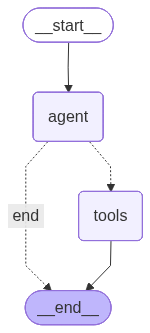

In [20]:
builder = StateGraph(AgentState)

# Nodes
tool_node = ToolNode([send_email])
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

# Edges
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "tools", "end": END},
)
builder.add_edge("tools", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Configurable thread ID
config: dict[str, Any] = {"configurable": {"thread_id": "email-workflow"}}

# Visualize the graph
try:
    display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    print(graph.get_graph(xray=1).draw_ascii())

#### Step 1: Start workflow


In [ ]:
initial = await graph.ainvoke(
    {"messages": [HumanMessage(content="Send an email to neidu@example.com about AI brainstorming meeting")]},
    config=config,
)

console.print("Step 1: Workflow interrupted")
if "__interrupt__" in initial:
    console.print("Interrupt details:", initial["__interrupt__"])

Step 1: Workflow interrupted

Interrupt details:
[
    Interrupt(
        value={
            'action': 'send_email',
            'to': 'neidu@example.com',
            'subject': 'AI Brainstorming Meeting',
            'body': "Hi Neidu,&#10;&#10;I wanted to schedule a brainstorming meeting about AI topics. Let's aim for
next week. Please suggest some times that work for you.&#10;&#10;Best,&#10;Chinedu",
            'message': 'Approve sending this email?'
        },
        id='bddf51feae0e61ccaad42678a34b4775'
    )
]

#### Step 2: Resume with approval


In [22]:
resumed = await graph.ainvoke(
    Command(
        resume={
            "action": Status.APPROVED,
            "subject": "Brainstorming Meeting Update",
        }
    ),
    config=config,
)
print(resumed["messages"][-1])

Sending email to=neidu@example.com with subject='Brainstorming Meeting Update' and body="Hi Neidu,&#10;&#10;I wanted to schedule a brainstorming meeting about AI topics. Let's aim for next week. Please suggest some times that work for you.&#10;&#10;Best,&#10;Chinedu"
content='Email sent to neidu@example.com.' name='send_email' tool_call_id='call_60510517'


### Using AsyncSqliteSaver

#### Note:

- It requires context manager and operations to run in a single thread

In [ ]:
async def demo_async_workflow() -> tuple[dict[str, Any], dict[str, Any] | None]:
    """Complete async workflow demonstration. It requires context manager for AsyncSqliteSaver."""
    # Use a simple file path instead of connection string
    async with AsyncSqliteSaver.from_conn_string("demo-async.db") as checkpointer:
        async_graph = builder.compile(checkpointer=checkpointer)

        config = {"configurable": {"thread_id": "async-email-workflow"}}

        # Step 1: Start workflow
        initial = await async_graph.ainvoke(
            {"messages": [HumanMessage(content="Send an email to async@example.com about async meeting")]},
            config=config,
        )

        console.print("[cyan]Async Step 1: Workflow interrupted[/cyan]")
        if "__interrupt__" in initial:
            print("Interrupt details:", initial["__interrupt__"])

            # Step 2: Resume with approval
            resumed = await async_graph.ainvoke(
                Command(
                    resume={
                        # "action": Status.APPROVED,
                        "action": "approved",
                        "subject": "Async Meeting Update",
                    }
                ),
                config=config,
            )
            console.print("Async Tool execution result:", style="info")
            print(resumed["messages"][-1])
        else:
            console.print("[red]No interrupt found in async workflow[/red]")
            resumed = None

        return initial, resumed


initial, resumed = await demo_async_workflow()

Async Step 1: Workflow interrupted

Interrupt details: [Interrupt(value={'action': 'send_email', 'to': 'async@example.com', 'subject': 'Async Meeting', 'body': "Hello, I'm reaching out once more about the async meeting. Previous messages may have been overlooked or cancelled. Please provide your availability so we can proceed. Thank you.", 'message': 'Approve sending this email?'}, id='085f4cc6c0aa9cf22a4adf029ab0f088')]
Sending email to=async@example.com with subject='Async Meeting Update' and body="Hello, I'm reaching out once more about the async meeting. Previous messages may have been overlooked or cancelled. Please provide your availability so we can proceed. Thank you."


Async Tool execution result:

content='Email sent to async@example.com.' name='send_email' tool_call_id='call_55422535'


## Validating Human Input Pattern

Sometimes you need to validate input from humans and ask again if it’s invalid. You can do this using multiple interrupt calls in a loop.

In [26]:
# ==================================================================
# ============================= STATE ==============================
# ==================================================================


class FormState(TypedDict):
    age: int


# ==================================================================
# ============================= NODES ==============================
# ==================================================================
def get_age_node(state: FormState) -> dict[str, Any]:
    prompt: str = " What is your age?"

    while True:
        answer: int | Any = interrupt(prompt)

        if isinstance(answer, int) and 1 <= answer <= 100:
            return {"age": answer}

        # Otherwise
        prompt: str = f"{answer!r} is not a valid age. Please enter a positive number."

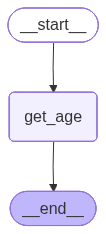

In [27]:
builder = StateGraph(FormState)

# Nodes
builder.add_node("get_age", get_age_node)

# Edges
builder.add_edge(START, "get_age")
builder.add_edge("get_age", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Configurable thread ID
config: dict[str, Any] = {"configurable": {"thread_id": "validate-human-input"}}

# Visualize the graph using nest_asyncio to handle event loop
try:
    display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    print(graph.get_graph(xray=1).draw_ascii())


# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

In [32]:
# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "validate-human-input"}}

response = await graph.ainvoke({"age": None}, config=config)

console.print(response)

{'age': None, '__interrupt__': [Interrupt(value=' What is your age?', id='c0b7b8829027861ec1d6fa86cfc4680a')]}

In [33]:
console.print(response["__interrupt__"])

[Interrupt(value=' What is your age?', id='c0b7b8829027861ec1d6fa86cfc4680a')]

#### Step 2: FIll the form

- With a valid input

In [35]:
resumed = await graph.ainvoke(Command(resume=20), config=config)
console.print(resumed)

{'age': 20}

#### Step 3: FIll the form 

- with an invalid input


In [37]:
# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "validate-human-input"}}

response = await graph.ainvoke({"age": None}, config=config)

console.print(response)

resumed = await graph.ainvoke(Command(resume="20"), config=config)
console.print(resumed)

{'age': None, '__interrupt__': [Interrupt(value=' What is your age?', id='507b17cdf6f8d5601d7c6313292cda2c')]}

{
    'age': None,
    '__interrupt__': [
        Interrupt(
            value="'20' is not a valid age. Please enter a positive number.",
            id='507b17cdf6f8d5601d7c6313292cda2c'
        )
    ]
}

## Rules of Interrupts

- [Docs](https://docs.langchain.com/oss/python/langgraph/interrupts#do-not-reorder-interrupt-calls-within-a-node)

When you call interrupt within a node, LangGraph suspends execution by raising an exception that signals the runtime to pause. This exception propagates up through the call stack and is caught by the runtime, which notifies the graph to save the current state and wait for external input.

- Do not wrap interrupt calls in try/except
- Do not reorder interrupt calls within a node
